In [1]:
from pathlib import Path
import json
from py_markdown_table.markdown_table import markdown_table
from numpy import load
from torch import from_numpy
from deepinv.utils.plotting import plot, plot_inset, preprocess_img

In [31]:
# Knee acc 6
ids_knee = {
    "MC": "q12j539v",
    "SSDU": "ux7wfivh",
    "Noise2Inverse": "1u0zlfb5",
    "Weighted-SSDU": "kxz615gz",
    "VORTEX": "bm5al0qy",
    "EI": "w46f0xqe",
    "MOI": "lcmutynf",
    "MO-EI (ours)": "ech941px",#"dijz21sj" #diffeo-mo-ei
    "(Supervised)": "jqht7upm",
    "temp": "dijz21sj"
}
# Knee reproducing SSDU
ids_knee_ssdu = {
    "SSDU (7)": "kb4pbb73",
    "Noise2Inverse (7)": "wfv8fwiv",
}
# Knee ablation
ids_knee_abl = {
    "EI (diffeo)": "6m6wcca7",
    "MO-EI (rotate)": "3mzavwml",
}
# Brain-knee transfer
ids_brkn_trans = {
    "Supervised": "muibu6sy",
    "Self-sup": "e4kz25ki",
    "Interleaved": "8ielvaed"
}

# Brain acc 6
ids_brain = {
    "MC": "jnmp1fqt",
    "SSDU": "1g8s1p2m",
    "Noise2Inverse": "68we1xso",
    "Weighted-SSDU": "26inuqs3",
    "Adversarial": "bo4m8jcq",
    "UAIR": "9ma7ndzl",
    "VORTEX": "8glarize",
    "EI": "oay0553s",
    "MOI": "12tm66pp",
    "MO-EI (ours)": "jbm1czk6", #"d6otk201", #diffeo-mo-ei
    "(Supervised)": "qmjy0ej1",
    "temp": "d6otk201"
}
# Brain reproducing SSDU
ids_brain_ssdu = {
    "SSDU (3)": "1g8s1p2m",
    "SSDU (7)": "wq0oh9fk",
    "Noise2Inverse (7)": "d9w3kn61",
    "Weighted-SSDU (3)": "26inuqs3",
    "Weighted-SSDU (7)": "bn8h36b7",
}
# Brain ablation
ids_brain_abl = {
    "MOI": "12tm66pp",
    "EI (rotate)": "oay0553s",
    "EI (diffeo)": "19wf0udg",
    "MO-EI (rotate)": "f0n546i7",
    "MO-EI (diffeo, ours)": "jbm1czk6",
}

chosen = "brain_ssdu"
ids = eval(f"ids_{chosen}")

Load results

In [32]:
filter_results = ("temp",)
filter_sample = ("MC", "Noise2Inverse", "EI (diffeo)", "MO-EI (rotate)", "VORTEX", "Adversarial", "UAIR")#, "Weighted-SSDU")

In [33]:
results = {}
for title, id in ids.items():
    with open(f"models/paper/{id}/results.json", "r") as f:
        results[title] = json.load(f)
    if title not in filter_sample:
        results[title]["sample"] = load(f"models/paper/{id}/samples.npz")

In [34]:
def repr(m, dp=3, p='+'):
    return f"{m:.{dp}f}".lstrip('0') if (m is not None and m != "") else ""
table = [{"name": "Zero-filled", "PSNR": repr(list(results.values())[0]["PSNR no learning"], 2), "SSIM": repr(list(results.values())[0]["SSIM no learning"], 4)} | {k: "" for k in ("PSNR2","PSNR3","SSIM2","SSIM3")}]
table += [
    {
        "name": k,
        "PSNR": repr(run["PSNR"], 2),
        "PSNR2": repr(run.get("PSNR2", ""), 2),
        "PSNR3": repr(run.get("PSNR3", ""), 2),
        "SSIM": repr(run["SSIM"], 4),
        "SSIM2": repr(run.get("SSIM2", ""), 4),
        "SSIM3": repr(run.get("SSIM3", ""), 4),
    } for k, run in results.items() if k not in filter_results
]
print(markdown_table(table).set_params(row_sep="markdown").get_markdown())

```|       name      | PSNR| SSIM|PSNR2|PSNR3|SSIM2|SSIM3|
|-----------------|-----|-----|-----|-----|-----|-----|
|   Zero-filled   |27.67|.7862|     |     |     |     |
|     SSDU (3)    |18.27|.4876|24.83|25.63|.6899|.7237|
|     SSDU (7)    |17.56|.4970|26.75|29.60|.7525|.8342|
|Noise2Inverse (7)|17.50|.4713|23.79|28.27|.6809|.7825|
|Weighted-SSDU (3)| 6.94|.2970|21.21|23.93|.5742|.6433|
|Weighted-SSDU (7)|29.44|.7822|29.35|30.78|.7837|.8042|```


In [35]:
for m in table:
    print(rf'{m["name"]} & {m["PSNR"]} & {m["SSIM"]} \\')

Zero-filled & 27.67 & .7862 \\
SSDU (3) & 18.27 & .4876 \\
SSDU (7) & 17.56 & .4970 \\
Noise2Inverse (7) & 17.50 & .4713 \\
Weighted-SSDU (3) & 6.94 & .2970 \\
Weighted-SSDU (7) & 29.44 & .7822 \\


In [39]:
for r in results.values():
    if "sample" in r and "x" in r["sample"]:
        x, x_init, y = from_numpy(r["sample"]["x"]), from_numpy(r["sample"]["x_init"]), from_numpy(r["sample"]["y"])
        break

plot_dict = {
    "Ground truth": x, 
    #"Mask": y != 0, 
    "Zero-filled": x_init
} | {
    k: from_numpy(results[k]["sample"]["x_hat"]) for k in results if k not in filter_sample + filter_results
}
labels = []#["", repr(list(results.values())[0]["PSNR no learning"], 2)] + [repr(results[k]["PSNR"], 2) for k in results if k not in filter_sample + filter_results]
#plot(plot_dict, save_fn=f"models/paper/results_{chosen}.png", dpi=1200)

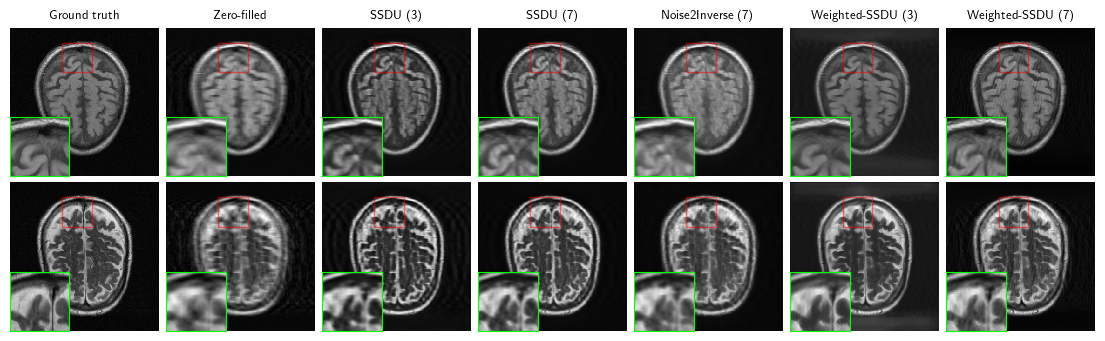

In [40]:
s =  [5, 19]#brain_ssdu [2, 5, 19]#brain [0,2]#brkn_trans [0, 2, 5]#knee
plot_inset([preprocess_img(i)[s] for i in plot_dict.values()], titles=list(plot_dict.keys()), dpi=600, save_fn=f"models/paper/results_{chosen}.png", labels=labels,
    #extract_loc=(0.1, 0.4), inset_loc=(0, 0.6) #knee
    extract_loc=(0.35, 0.1), inset_loc=(0, 0.6) #brain
    #extract_loc=(0.4, 0.45), inset_loc=(0, 0.6) #brkn_trans
)

Plot diffeomorphisms

In [ ]:
import deepinv as dinv
brain_dataset = dinv.datasets.SimpleFastMRISliceDataset("data", "brain", download=True)
xb = brain_dataset[0].unsqueeze(0)
d = dinv.transform.CPABDiffeomorphism(n_tesselation=2)
def crop(x, i=64):
    return x[...,i:-i,i:-i]
dinv.utils.plot([crop(xb), crop(d(xb)), x, d(x)], titles=["$\mathbf{x}$","$\mathbf{T}_g\mathbf{x}$","$\mathbf{x}$","$\mathbf{T}_g\mathbf{x}$"], dpi=600, save_fn="models/paper/transforms.png")